<a href="https://www.kaggle.com/code/adegbaju/line-level-code-vs-text-classification?scriptVersionId=299163276" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Line-Level Code vs. Text Classification

Binary classification: 0 = natural language, 1 = programming code

Don't forget upvote

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import make_pipeline

# 1. Load the dataset

In [2]:
df = pd.read_csv('/kaggle/input/line-level-code-vs-text-classification-dataset/code-vs-text.csv')  # update path if needed

# Remove rows with missing line content (very few)
df = df.dropna(subset=['line']).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())


Dataset shape: (52266, 3)
Columns: ['line', 'label', 'source']

First 5 rows:
                                                line  label  \
0                                             <View>      1   
1  Looking at further documentation, it seems tha...      0   
2  org.mockito.exceptions.misusing.WrongTypeOfRet...      1   
3  let randomArray = [1,2,4,591,392,391,2,5,10,2,...      1   
4  c.c:3:19: note: each undeclared identifier is ...      1   

               source  
0  stackoverflow_2020  
1  stackoverflow_2020  
2  stackoverflow_2020  
3  stackoverflow_2020  
4  stackoverflow_2020  


# 2. Exploratory Data Analysis (EDA)


--- Label Distribution ---
label
0    27328
1    24938
Name: count, dtype: int64
label
0    0.522864
1    0.477136
Name: proportion, dtype: float64

--- Source Distribution ---
source
stackoverflow_2020    32885
stackoverflow_2019    14698
twitch                 4683
Name: count, dtype: int64

--- Line Length (characters) ---
count    52266.000000
mean        59.531741
std         85.952399
min          1.000000
25%         17.000000
50%         34.000000
75%         72.000000
max       9082.000000
Name: line_length, dtype: float64


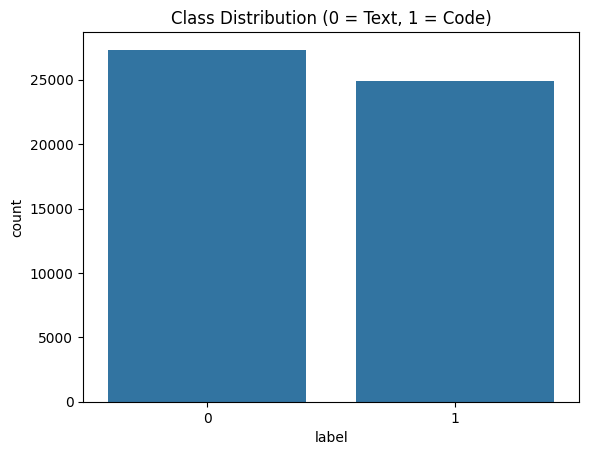

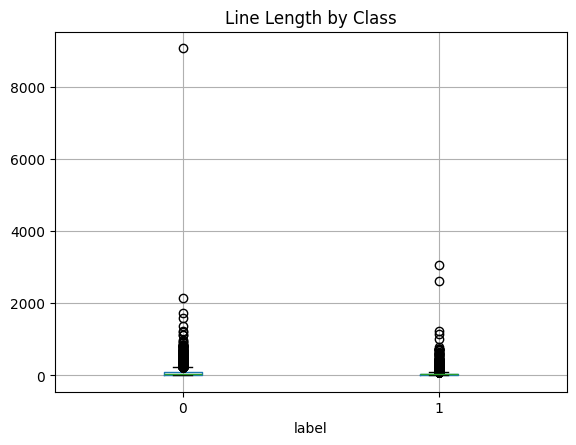

In [3]:

print("\n--- Label Distribution ---")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

print("\n--- Source Distribution ---")
print(df['source'].value_counts())

# Line length statistics
df['line_length'] = df['line'].str.len()
print("\n--- Line Length (characters) ---")
print(df['line_length'].describe(percentiles=[.25, .5, .75]))

# Visualise class balance
sns.countplot(x='label', data=df)
plt.title('Class Distribution (0 = Text, 1 = Code)')
plt.show()

# Visualise length by class
df.boxplot(column='line_length', by='label')
plt.title('Line Length by Class')
plt.suptitle('')
plt.show()

# 3. Train / Test Split

In [4]:

X = df['line']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 41812
Test set size: 10454


# 4. Build a TF-IDF + Logistic Regression Pipeline

In [5]:
# The vectorizer keeps punctuation and symbols (important for code).
# We limit to 5000 features for speed; you can increase it.
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',       # removes common English words (helps for text)
    ngram_range=(1, 2),         # unigrams and bigrams
    lowercase=True,             # convert to lowercase (code is case-sensitive? but helps generalisation)
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b'  # default token pattern (keeps alphanumeric tokens)
)

# Logistic Regression works well for high-dimensional sparse data
clf = LogisticRegression(max_iter=1000, random_state=42)

# Create pipeline
pipeline = make_pipeline(tfidf, clf)

# 5. Train the model

In [6]:
print("\nTraining the model...")
pipeline.fit(X_train, y_train)
print("Training complete.")


Training the model...
Training complete.


# 6. Evaluate on the test set


Test Accuracy: 0.8756

Classification Report:
              precision    recall  f1-score   support

        Text       0.91      0.84      0.88      5466
        Code       0.84      0.91      0.87      4988

    accuracy                           0.88     10454
   macro avg       0.88      0.88      0.88     10454
weighted avg       0.88      0.88      0.88     10454

Confusion Matrix:
[[4600  866]
 [ 435 4553]]


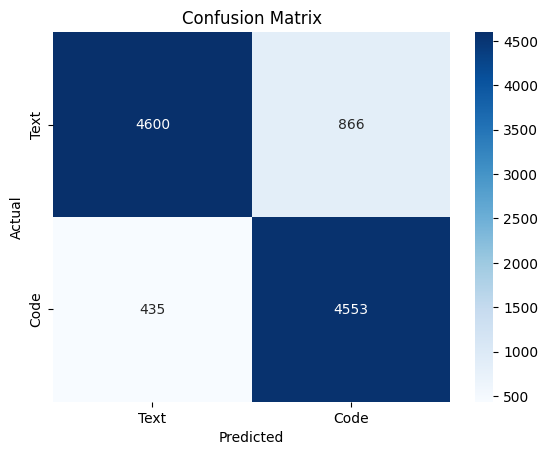

In [7]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Text', 'Code']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Text', 'Code'], yticklabels=['Text', 'Code'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# 7. Inspect misclassifications

In [8]:
misclassified = X_test[y_test != y_pred]
misclassified_labels = y_test[y_test != y_pred]
misclassified_pred = y_pred[y_test != y_pred]

print("\n--- Misclassified Examples (first 10) ---")
for i, (text, true, pred) in enumerate(zip(misclassified[:10], 
                                           misclassified_labels[:10], 
                                           misclassified_pred[:10])):
    print(f"{i+1}. True: {true} ({'Text' if true==0 else 'Code'}), Pred: {pred} ({'Text' if pred==0 else 'Code'})")
    print(f"   Line: {text[:200]}...")   # truncate long lines
    print()


--- Misclassified Examples (first 10) ---
1. True: 1 (Code), Pred: 0 (Text)
   Line: icon: 'ic_notification'...

2. True: 0 (Text), Pred: 1 (Code)
   Line: :...

3. True: 0 (Text), Pred: 1 (Code)
   Line: When I call checkTop( Derived ), its return type should be Derived. But with above jsdoc, its return type is 'typeof Derived'.
But I want to make the return type just 'Derived'....

4. True: 0 (Text), Pred: 1 (Code)
   Line: ]...

5. True: 1 (Code), Pred: 0 (Text)
   Line: .messages {...

6. True: 0 (Text), Pred: 1 (Code)
   Line: Caveat...

7. True: 0 (Text), Pred: 1 (Code)
   Line: And my handleScroll() method which manage all that...

8. True: 0 (Text), Pred: 1 (Code)
   Line: ?...

9. True: 0 (Text), Pred: 1 (Code)
   Line: Here is the code I have. It attempts to get the center point of the line and then the x, y, width, and height:...

10. True: 0 (Text), Pred: 1 (Code)
   Line: The calculation is (2 x Width) + (2 x Height). So from the above sizes of window, they need extrusion

# 8. Feature importance (most indicative words for each class)

In [9]:
feature_names = pipeline.named_steps['tfidfvectorizer'].get_feature_names_out()
coefficients = pipeline.named_steps['logisticregression'].coef_[0]

# Sort by coefficient value
top_positive = np.argsort(coefficients)[-20:]   # most code-like
top_negative = np.argsort(coefficients)[:20]    # most text-like

print("\nTop 20 features for CODE (positive coefficient):")
for i in top_positive:
    print(f"{feature_names[i]}: {coefficients[i]:.4f}")

print("\nTop 20 features for TEXT (negative coefficient):")
for i in top_negative:
    print(f"{feature_names[i]}: {coefficients[i]:.4f}")


Top 20 features for CODE (positive coefficient):
foo: 2.7661
append: 2.7738
res: 2.7871
print: 2.8010
com: 2.8151
def: 2.9330
np: 3.0245
id: 3.2550
div: 3.2703
org gradle: 3.2888
void: 3.7728
import: 3.8595
0: 4.0486
int: 4.0556
public: 4.1750
org: 4.4556
return: 4.6101
console log: 4.7172
const: 4.7547
var: 4.7927

Top 20 features for TEXT (negative coefficient):
following: -6.4494
like: -5.8924
way: -5.8212
trying: -5.5213
want: -5.2104
edit: -4.6075
problem: -4.4201
ve: -4.3808
does: -4.3312
different: -4.2715
tried: -4.2001
issue: -3.9828
know: -3.9629
pog: -3.9340
working: -3.9070
thanks: -3.9009
just: -3.8954
question: -3.8489
possible: -3.7611
update: -3.7499


# 9. Test on custom examples

In [10]:

def predict_line(line):
    pred = pipeline.predict([line])[0]
    prob = pipeline.predict_proba([line])[0]
    return pred, prob

print("\n--- Predictions on custom lines ---")
examples = [
    "print('Hello, world!')",
    "Hello, how are you today?",
    "def factorial(n): return 1 if n <= 1 else n * factorial(n-1)",
    "The quick brown fox jumps over the lazy dog.",
    "std::vector<int> v = {1,2,3};",
    "I think this is a bug in the compiler.",
]

for ex in examples:
    pred, prob = predict_line(ex)
    label = "Code" if pred == 1 else "Text"
    print(f"\nLine: {ex}")
    print(f"Prediction: {label} (confidence: {prob[pred]:.4f})")


--- Predictions on custom lines ---

Line: print('Hello, world!')
Prediction: Code (confidence: 0.8998)

Line: Hello, how are you today?
Prediction: Code (confidence: 0.5144)

Line: def factorial(n): return 1 if n <= 1 else n * factorial(n-1)
Prediction: Code (confidence: 0.9708)

Line: The quick brown fox jumps over the lazy dog.
Prediction: Text (confidence: 0.6410)

Line: std::vector<int> v = {1,2,3};
Prediction: Code (confidence: 0.9724)

Line: I think this is a bug in the compiler.
Prediction: Text (confidence: 0.9382)
